# Data Cleaning

In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Swasthya-Matrix-Training") \
    .getOrCreate()

df = spark.read.csv("data_hmis.csv", header=True, inferSchema=True)
df.show(5)
print("Dataset loaded successfully and first 5 rows displayed.")

+-------------+--------+-----------+--------------+--------------+-------------+---------+---------------+-------------+--------+-------------------+-------------------+---------------+-------------------+----------------------+----------------+-----------------------+---------------+----------------------+
|        State|   Month|Region_Type|ANC_Registered|Adult_Death_TB|Adult_Suicide|C_Section|Child_Diarrhoea|Child_Malaria|Child_TB|Condoms_Distributed|Early_Breastfeeding|Immunization_MR|Infant_Death_Sepsis|Institutional_Delivery|Low_Birth_Weight|Maternal_Death_Bleeding|PW_Hypertension|Severe_Anaemia_Treated|
+-------------+--------+-----------+--------------+--------------+-------------+---------+---------------+-------------+--------+-------------------+-------------------+---------------+-------------------+----------------------+----------------+-----------------------+---------------+----------------------+
|A & N Islands|   April|      Rural|         315.0|           1.0|       

In [7]:
from pyspark.sql.types import IntegerType, DoubleType

numerical_cols = [field.name for field in df.schema if isinstance(field.dataType, (IntegerType, DoubleType))]

print("Identified Numerical Columns:", numerical_cols)

Identified Numerical Columns: ['ANC_Registered', 'Adult_Death_TB', 'Adult_Suicide', 'C_Section', 'Child_Diarrhoea', 'Child_Malaria', 'Child_TB', 'Condoms_Distributed', 'Early_Breastfeeding', 'Immunization_MR', 'Infant_Death_Sepsis', 'Institutional_Delivery', 'Low_Birth_Weight', 'Maternal_Death_Bleeding', 'PW_Hypertension', 'Severe_Anaemia_Treated']


In [8]:
from pyspark.sql.functions import col

initial_row_count = df.count()
print(f"Initial number of rows: {initial_row_count}")

filter_condition = None
for col_name in numerical_cols:
    if filter_condition is None:
        filter_condition = (col(col_name) != 0.0)
    else:
        filter_condition = filter_condition | (col(col_name) != 0.0)

df_cleaned = df.filter(filter_condition)

cleaned_row_count = df_cleaned.count()
print(f"Number of rows after cleaning: {cleaned_row_count}")

rows_removed = initial_row_count - cleaned_row_count
print(f"Number of rows removed: {rows_removed}")

print("First 5 rows of the cleaned DataFrame:")
df_cleaned.show(5)

print("Data cleaning operation summarized.")

Initial number of rows: 912
Number of rows after cleaning: 852
Number of rows removed: 60
First 5 rows of the cleaned DataFrame:
+-------------+--------+-----------+--------------+--------------+-------------+---------+---------------+-------------+--------+-------------------+-------------------+---------------+-------------------+----------------------+----------------+-----------------------+---------------+----------------------+
|        State|   Month|Region_Type|ANC_Registered|Adult_Death_TB|Adult_Suicide|C_Section|Child_Diarrhoea|Child_Malaria|Child_TB|Condoms_Distributed|Early_Breastfeeding|Immunization_MR|Infant_Death_Sepsis|Institutional_Delivery|Low_Birth_Weight|Maternal_Death_Bleeding|PW_Hypertension|Severe_Anaemia_Treated|
+-------------+--------+-----------+--------------+--------------+-------------+---------+---------------+-------------+--------+-------------------+-------------------+---------------+-------------------+----------------------+----------------+--------

In [9]:
df_cleaned.write.csv("data_hmis_cleaned.csv", header=True, mode="overwrite")
print("df_cleaned dataset saved as data_hmis_cleaned.csv")

df_cleaned dataset saved as data_hmis_cleaned.csv


# Kmeans Clustering

In [10]:
!pip install pyspark matplotlib seaborn pandas

from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spark = SparkSession.builder \
    .appName("Swasthya-Matrix-Training") \
    .getOrCreate()

print("Spark Session created successfully!")

Spark Session created successfully!


In [11]:
df = spark.read.csv("cleaned_data_hmis.csv", header=True, inferSchema=True)

indexer = StringIndexer(inputCol="Region_Type", outputCol="Region_Index")
df_indexed = indexer.fit(df).transform(df)

feature_cols = [
    'ANC_Registered', 'Institutional_Delivery', 'C_Section', 'Child_Diarrhoea',
    'Child_TB', 'Immunization_MR', 'Low_Birth_Weight', 'Infant_Death_Sepsis',
    'Maternal_Death_Bleeding', 'Adult_Death_TB', 'Adult_Suicide', 'PW_Hypertension',
    'Child_Malaria', 'Severe_Anaemia_Treated', 'Condoms_Distributed', 'Early_Breastfeeding',
    'Region_Index'
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
df_assembled = assembler.transform(df_indexed)

scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

print("Data successfully vectorized and scaled!")

Data successfully vectorized and scaled!


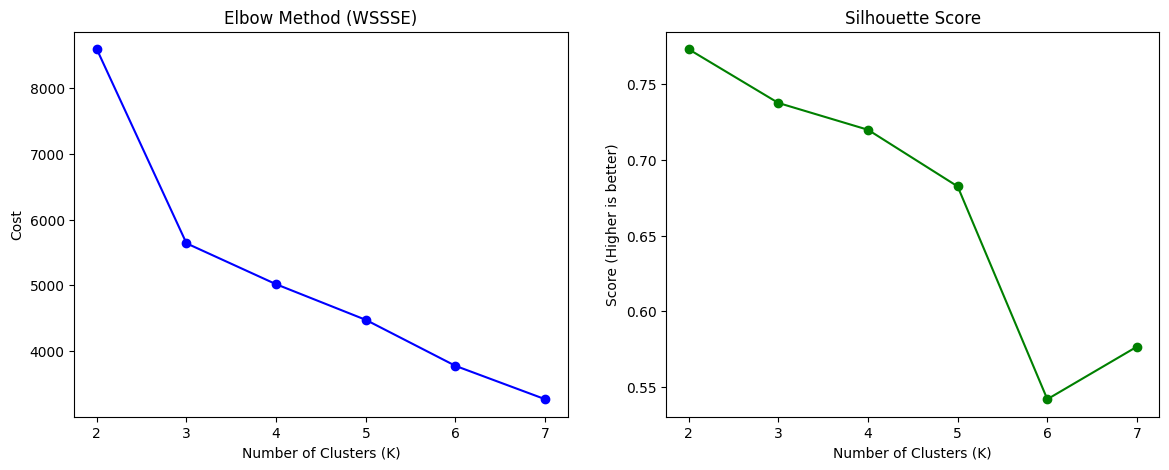

In [12]:
cost = []
silhouette_scores = []
evaluator = ClusteringEvaluator()

for k in range(2, 8):
    kmeans = KMeans().setK(k).setSeed(42).setFeaturesCol("features")
    model = kmeans.fit(df_scaled)

    cost.append(model.summary.trainingCost)

    predictions = model.transform(df_scaled)
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(2, 8), cost, marker='o', color='blue')
ax[0].set_title('Elbow Method (WSSSE)')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Cost')

ax[1].plot(range(2, 8), silhouette_scores, marker='o', color='green')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Score (Higher is better)')

plt.show()

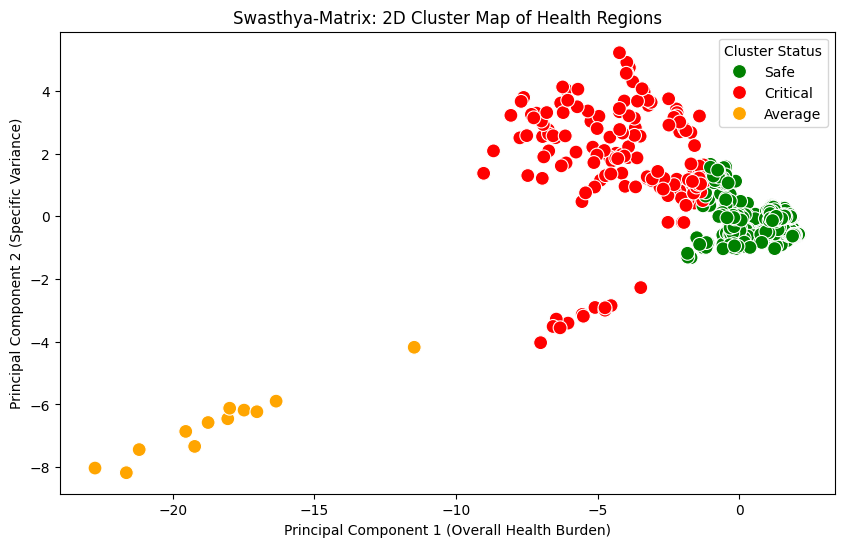

In [15]:
# Train final model with K=3
final_kmeans = KMeans().setK(3).setSeed(42).setFeaturesCol("features")
final_model = final_kmeans.fit(df_scaled)

predictions = final_model.transform(df_scaled)

pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(predictions)
pca_result = pca_model.transform(predictions)

x_coords = pca_result.select("pca_features").rdd.map(lambda row: float(row[0][0])).collect()
y_coords = pca_result.select("pca_features").rdd.map(lambda row: float(row[0][1])).collect()
cluster_labels = pca_result.select("prediction").rdd.map(lambda row: int(row[0])).collect()

plot_df = pd.DataFrame({'PCA1': x_coords, 'PCA2': y_coords, 'Cluster': cluster_labels})

label_map = {0: 'Safe', 1: 'Critical', 2: 'Average'}
plot_df['Health_Status'] = plot_df['Cluster'].map(label_map)

color_map = {'Critical': 'red', 'Safe': 'green', 'Average': 'orange'}

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='PCA1', y='PCA2', hue='Health_Status', palette=color_map, s=100)
plt.title("Swasthya-Matrix: 2D Cluster Map of Health Regions")
plt.xlabel("Principal Component 1 (Overall Health Burden)")
plt.ylabel("Principal Component 2 (Specific Variance)")
plt.legend(title="Cluster Status")
plt.show()

In [16]:
import pyspark.sql.functions as F

cluster_analysis = predictions.groupBy("prediction").agg(
    F.avg("Child_Diarrhoea").alias("Avg_Diarrhoea"),
    F.avg("Adult_Death_TB").alias("Avg_TB_Deaths"),
    F.avg("Infant_Death_Sepsis").alias("Avg_Infant_Deaths"),
    F.avg("Institutional_Delivery").alias("Avg_Safe_Deliveries"),
    F.avg("Immunization_MR").alias("Avg_Immunization")
).orderBy("prediction")

cluster_analysis.show()

+----------+------------------+------------------+------------------+-------------------+------------------+
|prediction|     Avg_Diarrhoea|     Avg_TB_Deaths| Avg_Infant_Deaths|Avg_Safe_Deliveries|  Avg_Immunization|
+----------+------------------+------------------+------------------+-------------------+------------------+
|         0|1484.3186490455214| 8.634361233480176| 5.694566813509545| 10817.624082232012|10733.612334801763|
|         1|15196.666666666666|109.05660377358491|105.72955974842768| 61546.811320754714| 74499.44025157233|
|         2|           35149.0| 72.33333333333333|             59.75|          256193.25|          379571.5|
+----------+------------------+------------------+------------------+-------------------+------------------+



In [17]:
final_model.write().overwrite().save("swasthya_kmeans.model")
scaler_model.write().overwrite().save("swasthya_kmeans_scaler.model")

print("Models successfully saved!")

Models successfully saved!
